In [211]:
## Introduction
'''
    Descion Tree Model:
        - don't require us to scale or normalize our data.
        - Handle Missing Data
    
    For my Case of 500K row in dataset --> DT is overfitting (high memory usage, ...)
        --> Solution: Random Forest Regressor
'''
# src: https://data36.com/regression-tree-python-scikit-learn/

"\n    Descion Tree Model:\n        - don't require us to scale or normalize our data.\n        - Handle Missing Data\n    \n    For my Case of 500K row in dataset --> DT is overfitting (high memory usage, ...)\n        --> Solution: Random Forest Regressor\n"

### Desion Tree Regression

In [191]:
# Import Package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [192]:
data = pd.read_csv("Games.csv")
data = data.drop("Unnamed: 0", axis=1)

Text(0, 0.5, 'profit')

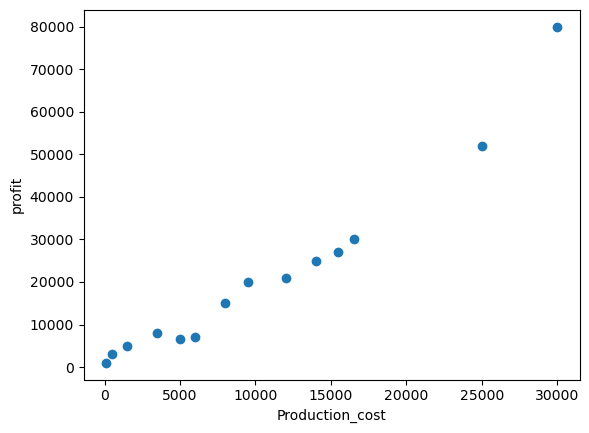

In [193]:
data
plt.scatter("Production_cost", "profit", data=data)
plt.xlabel("Production_cost")
plt.ylabel("profit")

In [194]:
# import Descion Tree Regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [195]:
# Extract Features
X = data.drop(["profit"], axis=1)
X
y = data["profit"]
y

0      1000
1      3000
2      5000
3      8000
4      6500
5      7000
6     15000
7     20000
8     21000
9     25000
10    27000
11    30000
12    52000
13    80000
Name: profit, dtype: int64

In [208]:
'''
    - take 30% of test and let 70% in train set
'''

# Method1: Label Encoding --> Gender
le = LabelEncoder()
X["Genre"] = le.fit_transform(X["Genre"])

# Method2: Mapping Each Attribute With Number
# genre_list = X["Genre"].to_list()
# genre_list_dict = {}
# print(genre_list_dict)
# counter = 0
# for index, value in enumerate(genre_list):
#     if (genre_list_dict.get(value) is None):
#         genre_list_dict[value] = counter
#         counter += 1
# print(genre_list_dict)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=44)

In [ ]:
# Creating a Descion Tree Regression Model
'''
    DecisionTreeRegressor: accept just numbers
        --> for columns that have character we need Encoding
        --> Encoding: is just a mapping technique

    Parameter Explination:
        - min_samples_split=3: a node must have at least 3 records to try splitting into new nodes

        - random_state = 0: python does not calcute the varaince for to get best feature as node it pick random number for example
        - random_state = 5 --> python will make 5 times random feature and check is it best or no without calcuting the varaince.
            IN CASE if splitter="best" --> based on varaince we get feature as node.

        - splitter="best": get best feature un root as node by checking error --> calcute
            varaince for each featre again.

        - min_samples_leaf=2: each leaf or child must have at least 2 records.
'''
model = DecisionTreeRegressor(random_state=0, min_samples_split=3, splitter="best", min_samples_leaf=3)

'\n    DecisionTreeRegressor: accept just numbers\n        --> for columns that have character we need Encoding\n        --> Encoding: is just a mapping technique\n\n    Parameter Explination:\n        - min_samples_split=3: a node must have at least 3 records to try splitting into new nodes\n\n        - random_state=0: python does not calcute the varaince for to get best feature as node it pick random number for example random_state = 5 --> python will make 5 times random feature and check is it best or no without calcuting the varaince. IN CASE if splitter="best" --> based on varaince we get feature as node.\n\n        - splitter="best": get best feature un root as node by checking error --> calcute\n            varaince for each featre again.\n\n        - min_samples_leaf=2: each leaf or child must have at least 2 records.\n'

In [ ]:
model = DecisionTreeRegressor(random_state=44)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
X_test
print(predictions)

[ 5000. 25000.  6500.  5000. 25000.]
